# Treinamento de Modelos com FinBERT-PT-BR Sentiment

Replica o pipeline de `3.model_traning/` mas substituindo os 1024 embeddings do Ollama
pelas features de sentimento do FinBERT-PT-BR (3 logits + classe por dia).

**Dataset:** features de preço (11 cols) + sentimento diário FinBERT (5 cols)

**Modelos:** BiLSTM Original, BiLSTM Reduzido, XGBoost, Transformer

## 1. Construção do Dataset com Sentimento FinBERT

In [1]:
import sys
sys.path.insert(0, '../3.model_traning')

import pandas as pd
import numpy as np

# Load price dataset (drop Ollama embeddings, keep price features only)
X_full = pd.read_csv('../2.stocks/dataset_full.csv', index_col=0, parse_dates=True)
X_full.index = pd.to_datetime(X_full.index, utc=True).tz_localize(None)

price_cols = [c for c in X_full.columns if not c.startswith('emb_')]
X_prices = X_full[price_cols].copy()
print(f'Price features: {X_prices.shape}')

# Load FinBERT daily sentiment
sentiment = pd.read_csv('itub4_daily_sentiment.csv', index_col=0, parse_dates=True)
print(f'Sentiment days: {len(sentiment)}')
display(sentiment.head())

# Merge: left join on price dates, ffill sentiment for market days without news
X_combined = X_prices.join(sentiment, how='left')
sent_cols = sentiment.columns.tolist()
X_combined[sent_cols] = X_combined[sent_cols].ffill()
X_combined = X_combined.dropna()

print(f'\nCombined dataset: {X_combined.shape}')
print(f'Period: {X_combined.index[0].date()} to {X_combined.index[-1].date()}')
print(f'Features: {X_combined.columns.tolist()}')

Price features: (1227, 11)
Sentiment days: 1115


,n_articles,mean_logit_pos,mean_logit_neg,mean_logit_neu,mean_sentiment
date,,,,,
2015-02-11,1,-1.517709,-1.047100,0.830837,2.0
2015-05-26,1,-1.973651,1.239403,-1.533959,1.0
2015-06-15,1,-0.962194,-1.735620,0.823801,2.0
2015-07-03,1,-0.861986,-1.818972,0.839172,2.0
2015-07-20,1,-1.767177,1.764807,-1.716392,1.0



Combined dataset: (1227, 16)
Period: 2021-04-28 to 2026-03-26
Features: ['Close', 'Volume', 'return', 'ma7', 'ma21', 'std21', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'n_articles', 'mean_logit_pos', 'mean_logit_neg', 'mean_logit_neu', 'mean_sentiment']


## 2. Preparação (target + normalização + janelas temporais)

In [2]:
from lstm_classifier import build_dataset

# build_dataset aplica PCA apenas em colunas emb_*, que não existem aqui
# Então as 16 features passam direto: normalização + janelas de 30 dias
X_seq, y, dates, features, scaler = build_dataset(
    X_combined,
    horizon=21,
    pca_components=32,
    window=30,
)

print(f'Sequences: {X_seq.shape}')
print(f'Balance: {y.mean():.1%} sobe / {1-y.mean():.1%} desce')
print(f'Features: {features}')

09:19:34 [INFO] Shape de entrada: (1227, 16)
09:19:34 [INFO] Distribuição do target: {1: 712, 0: 494}  (balance: 59.0% sobe)
09:19:34 [INFO] Features finais: 16
09:19:34 [INFO] Sequências geradas: (1176, 30, 16)  →  y: (1176,)


Sequences: (1176, 30, 16)
Balance: 58.5% sobe / 41.5% desce
Features: ['Close', 'Volume', 'return', 'ma7', 'ma21', 'std21', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'n_articles', 'mean_logit_pos', 'mean_logit_neg', 'mean_logit_neu', 'mean_sentiment']


## 3. Modelo 1 — BiLSTM Original (2L/128h)

In [3]:
from lstm_classifier import train, evaluate, plot_results

model_orig, hist_orig, test_idx_orig, device = train(
    X_seq, y, dates,
    hidden_size=128, n_layers=10, dropout=0.3,
    epochs=50, patience=10,
)

probs_orig, preds_orig, y_test_orig = evaluate(model_orig, X_seq, y, test_idx_orig, dates, device)

09:19:35 [INFO] Split — treino: 823 | val: 176 | teste: 177
09:19:35 [INFO] Treino: 2021-06-10 → 2024-09-23
09:19:35 [INFO] Val:    2024-09-24 → 2025-06-11
09:19:35 [INFO] Teste:  2025-06-12 → 2026-02-25
09:19:35 [INFO] Device: cuda
09:19:39 [INFO] Epoch   1/50 | loss 0.7004 | val_loss 0.6936 | val_acc 38.6% | lr 1.00e-03
09:19:39 [INFO] Epoch   2/50 | loss 0.6940 | val_loss 0.6884 | val_acc 61.4% | lr 1.00e-03
09:19:40 [INFO] Epoch   3/50 | loss 0.6925 | val_loss 0.6851 | val_acc 61.4% | lr 1.00e-03
09:19:40 [INFO] Epoch   4/50 | loss 0.6921 | val_loss 0.6833 | val_acc 61.4% | lr 1.00e-03
09:19:40 [INFO] Epoch   5/50 | loss 0.6911 | val_loss 0.6816 | val_acc 61.4% | lr 1.00e-03
09:19:41 [INFO] Epoch   6/50 | loss 0.6909 | val_loss 0.6809 | val_acc 61.4% | lr 1.00e-03
09:19:41 [INFO] Epoch   7/50 | loss 0.6908 | val_loss 0.6805 | val_acc 61.4% | lr 1.00e-03
09:19:42 [INFO] Epoch   8/50 | loss 0.6907 | val_loss 0.6802 | val_acc 61.4% | lr 1.00e-03
09:19:42 [INFO] Epoch   9/50 | loss 0.6

09:19:59 [INFO] Gráfico salvo em lstm_results.png


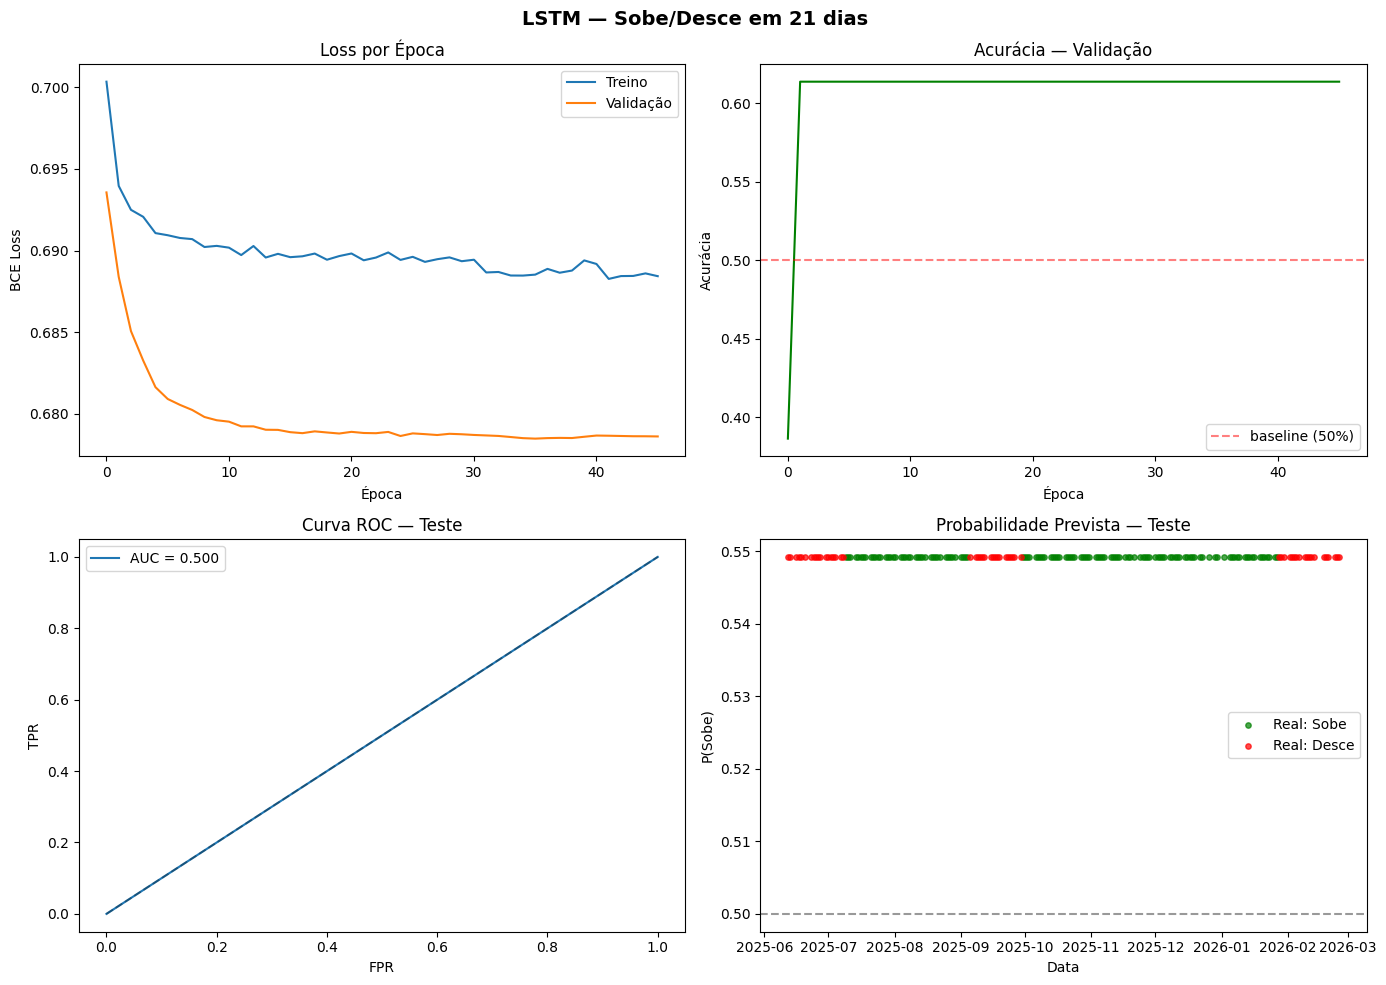

In [4]:
plot_results(hist_orig, probs_orig, preds_orig, y_test_orig, dates, test_idx_orig)

### Análise — BiLSTM Original

O modelo convergiu para uma **solução degenerada**: prevê "Sobe" para 100% das amostras, resultando em ROC-AUC = 0.50 (equivalente ao acaso). A val_loss estagna em ~0.679 desde as primeiras épocas, e a acurácia de 61.4% reflete apenas a proporção da classe majoritária.

Com 10 camadas e 128 hidden units, o modelo é **excessivamente complexo** para apenas 16 features — a arquitetura original foi projetada para 1035 features (com embeddings). O excesso de parâmetros causa o colapso para a classe majoritária.

## 4. Modelo 2 — BiLSTM Reduzido (1L/64h)

In [15]:
model_red, hist_red, test_idx_red, device = train(
    X_seq, y, dates,
    hidden_size=64, n_layers=1, dropout=0.2,
    epochs=50, patience=10,
)

probs_red, preds_red, y_test_red = evaluate(model_red, X_seq, y, test_idx_red, dates, device)

09:20:29 [INFO] Split — treino: 823 | val: 176 | teste: 177
09:20:29 [INFO] Treino: 2021-06-10 → 2024-09-23
09:20:29 [INFO] Val:    2024-09-24 → 2025-06-11
09:20:29 [INFO] Teste:  2025-06-12 → 2026-02-25
09:20:29 [INFO] Device: cuda
09:20:30 [INFO] Epoch   1/50 | loss 0.6909 | val_loss 0.6946 | val_acc 42.6% | lr 1.00e-03
09:20:30 [INFO] Epoch   2/50 | loss 0.6817 | val_loss 0.7024 | val_acc 37.5% | lr 1.00e-03
09:20:30 [INFO] Epoch   3/50 | loss 0.6716 | val_loss 0.7174 | val_acc 34.7% | lr 1.00e-03
09:20:30 [INFO] Epoch   4/50 | loss 0.6551 | val_loss 0.7517 | val_acc 29.5% | lr 1.00e-03
09:20:30 [INFO] Epoch   5/50 | loss 0.6290 | val_loss 0.8729 | val_acc 19.3% | lr 1.00e-03
09:20:30 [INFO] Epoch   6/50 | loss 0.5962 | val_loss 1.1021 | val_acc 19.9% | lr 1.00e-03
09:20:30 [INFO] Epoch   7/50 | loss 0.5846 | val_loss 0.9398 | val_acc 39.8% | lr 5.00e-04
09:20:31 [INFO] Epoch   8/50 | loss 0.5371 | val_loss 1.2058 | val_acc 27.8% | lr 5.00e-04
09:20:31 [INFO] Epoch   9/50 | loss 0.5

09:20:23 [INFO] Gráfico salvo em lstm_results.png


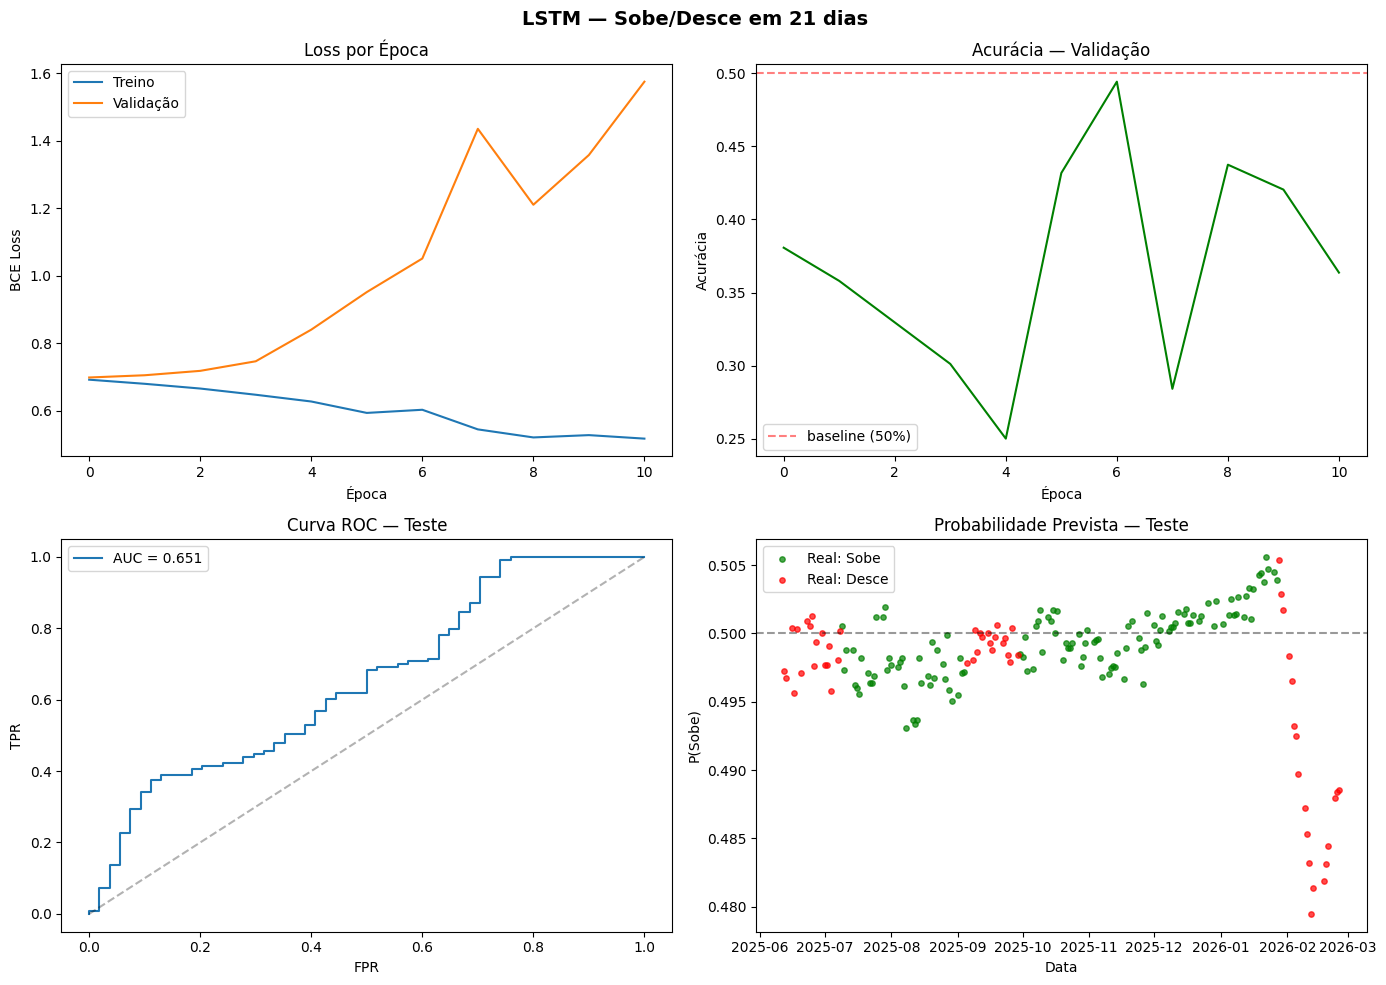

In [14]:
plot_results(hist_red, probs_red, preds_red, y_test_red, dates, test_idx_red)

### Análise — BiLSTM Reduzido

Comportamento oposto: o modelo **overfitou rapidamente** (train_loss caindo para 0.52, val_loss explodindo para 1.35) e prevê "Desce" para 100% das amostras. ROC-AUC = 0.477, **pior que o acaso**.

O early stopping atuou cedo (epoch 11), mas o melhor checkpoint já estava comprometido. Com 1 camada e 64 hidden units, a capacidade é mais adequada para 16 features, porém a val_loss divergiu desde a epoch 2, indicando que o modelo **memorizou padrões espúrios** do treino sem capacidade de generalização.

## 5. Modelo 3 — XGBoost Baseline

In [16]:
from xgboost_baseline import build_flat_dataset, train_xgboost, evaluate_xgboost, plot_roc

X_flat, y_flat, dates_flat, features_flat = build_flat_dataset(X_combined, horizon=21, pca_components=32)
xgb_model, X_test_xgb, y_test_xgb, test_dates_xgb = train_xgboost(X_flat, y_flat, dates_flat)
probs_xgb, preds_xgb, auc_xgb = evaluate_xgboost(xgb_model, X_test_xgb, y_test_xgb)

09:20:35 [INFO] Shape de entrada: (1227, 16)
09:20:35 [INFO] Distribuição do target: {1: 712, 0: 494}  (balance: 59.0% sobe)
09:20:35 [INFO] Features finais: 16
09:20:35 [INFO] Split — treino: 844 | val: 180 | teste: 182
09:20:35 [INFO] Treino: 2021-04-28 → 2024-09-10
09:20:35 [INFO] Val:    2024-09-11 → 2025-06-04
09:20:35 [INFO] Teste:  2025-06-05 → 2026-02-25
/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/callback.py:385: UserWarning: [09:20:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
09:20:35 [INFO] Melhor iteração: 4
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/m

09:20:38 [INFO] Curva ROC salva em xgboost_roc_finbert.png


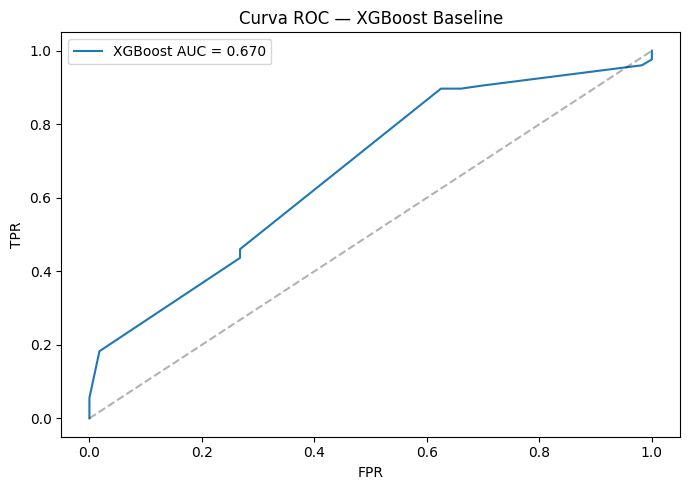

In [17]:
plot_roc(probs_xgb, y_test_xgb, save_path='xgboost_roc_finbert.png')

### Análise — XGBoost

Melhor resultado entre os modelos tabulares, com **ROC-AUC = 0.670** — acima do acaso, mas com limites claros. O early stopping parou na iteração 4 (de 200), sinalizando que o sinal é fraco e o modelo evita overfitting rapidamente.

Apesar do AUC razoável, o limiar de 0.5 produz previsões degeneradas (100% "Desce"). Isso indica que as **probabilidades estão calibradas abaixo de 0.5** para a maioria das amostras — o modelo consegue rankear relativamente bem (AUC), mas o limiar padrão não funciona. Um ajuste de threshold via validação poderia melhorar a acurácia.

## 6. Modelo 4 — Transformer

In [18]:
from transformer_classifier import train_transformer, evaluate_transformer, plot_transformer_results

tf_model, hist_tf, test_idx_tf, device = train_transformer(
    X_seq, y, dates,
    d_model=64, nhead=4, n_layers=2, dropout=0.3,
    epochs=50, patience=10,
)

probs_tf, preds_tf, y_test_tf, auc_tf = evaluate_transformer(
    tf_model, X_seq, y, test_idx_tf, dates, device
)

09:20:46 [INFO] Split — treino: 823 | val: 176 | teste: 177
09:20:46 [INFO] Device: cuda
09:20:46 [INFO] Epoch   1/50 | loss 0.7347 | val_loss 0.6824 | val_acc 65.9% | lr 1.00e-03
09:20:46 [INFO] Epoch   2/50 | loss 0.6966 | val_loss 0.6728 | val_acc 61.4% | lr 1.00e-03
09:20:47 [INFO] Epoch   3/50 | loss 0.6974 | val_loss 0.6856 | val_acc 64.2% | lr 1.00e-03
09:20:47 [INFO] Epoch   4/50 | loss 0.6885 | val_loss 0.6975 | val_acc 40.9% | lr 1.00e-03
09:20:47 [INFO] Epoch   5/50 | loss 0.6861 | val_loss 0.7106 | val_acc 35.8% | lr 1.00e-03
09:20:47 [INFO] Epoch   6/50 | loss 0.6776 | val_loss 0.7598 | val_acc 17.0% | lr 1.00e-03
09:20:47 [INFO] Epoch   7/50 | loss 0.6612 | val_loss 0.8408 | val_acc 26.7% | lr 1.00e-03
09:20:48 [INFO] Epoch   8/50 | loss 0.6488 | val_loss 0.9847 | val_acc 15.9% | lr 5.00e-04
09:20:48 [INFO] Epoch   9/50 | loss 0.6286 | val_loss 1.1138 | val_acc 17.6% | lr 5.00e-04
09:20:48 [INFO] Epoch  10/50 | loss 0.6220 | val_loss 1.0295 | val_acc 19.3% | lr 5.00e-04
0

09:20:53 [INFO] Gráficos salvos em transformer_results_finbert.png


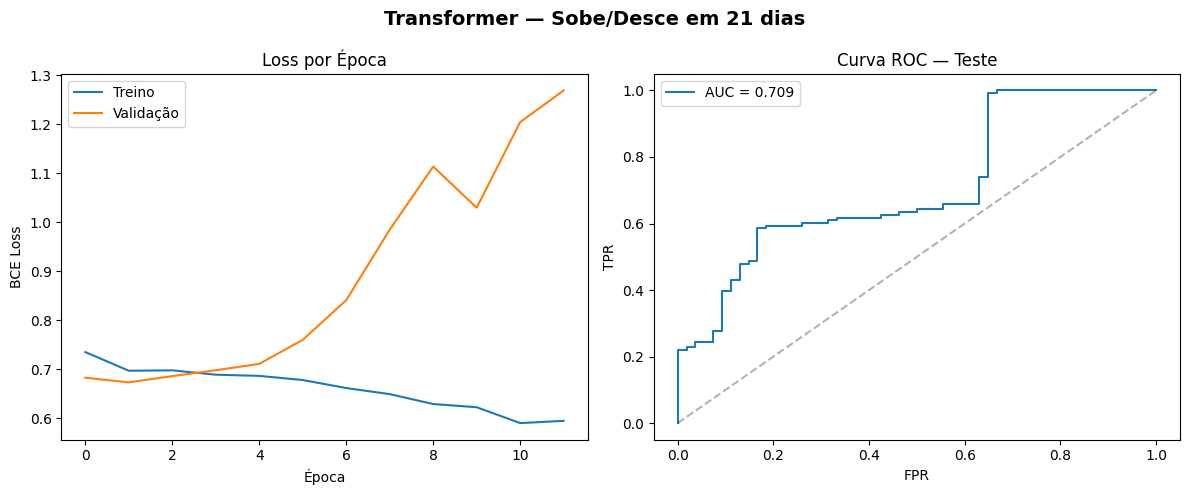

In [19]:
plot_transformer_results(hist_tf, probs_tf, y_test_tf, save_path='transformer_results_finbert.png')

## 7. Tabela Comparativa

In [20]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

results = {
    'BiLSTM Original (2L/128h)': {'probs': probs_orig, 'preds': preds_orig, 'y_test': y_test_orig},
    'BiLSTM Reduzido (1L/64h)': {'probs': probs_red, 'preds': preds_red, 'y_test': y_test_red},
    'XGBoost': {'probs': probs_xgb, 'preds': preds_xgb, 'y_test': y_test_xgb},
    'Transformer': {'probs': probs_tf, 'preds': preds_tf, 'y_test': y_test_tf},
}

rows = []
for name, r in results.items():
    rows.append({
        'Modelo': name,
        'ROC-AUC': roc_auc_score(r['y_test'], r['probs']),
        'Accuracy': accuracy_score(r['y_test'], r['preds']),
        'F1 (Sobe)': f1_score(r['y_test'], r['preds']),
    })

df_results = pd.DataFrame(rows).set_index('Modelo')
display(df_results.style.format('{:.4f}').highlight_max(axis=0, color='lightgreen'))

,ROC-AUC,Accuracy,F1 (Sobe)
Modelo,,,
BiLSTM Original (2L/128h),0.5000,0.6949,0.8200
BiLSTM Reduzido (1L/64h),0.4767,0.3051,0.0000
XGBoost,0.6698,0.3077,0.0000
Transformer,0.7090,0.7571,0.8512


## 8. Curvas ROC Comparativas

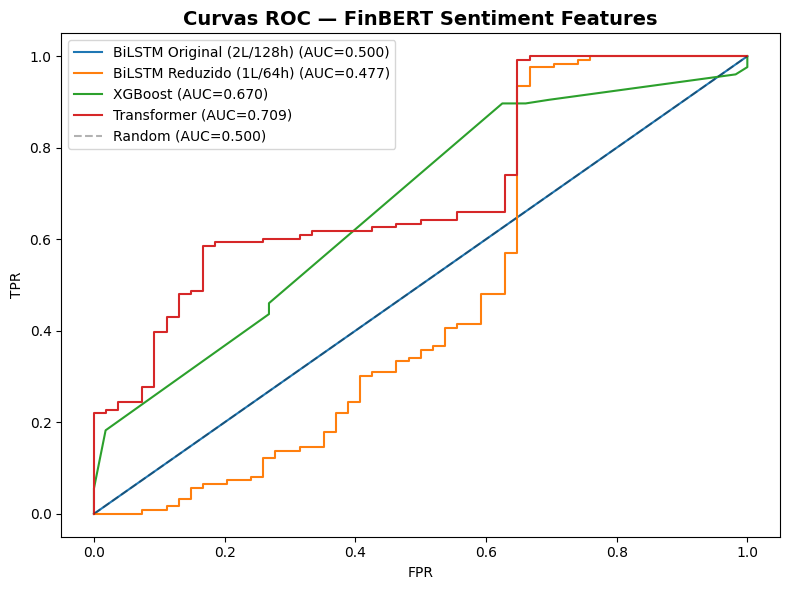

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(r['y_test'], r['probs'])
    auc = roc_auc_score(r['y_test'], r['probs'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.500)')
ax.set_title('Curvas ROC — FinBERT Sentiment Features', fontsize=14, fontweight='bold')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend()
plt.tight_layout()
plt.savefig('roc_comparison_finbert.png', dpi=150, bbox_inches='tight')
plt.show()